In [59]:
import pandas as pd
import numpy as np

# Load dữ liệu Chatlog đã ẩn danh
csv_path = r"data\vlearn-pack\chatlog\chat_history_anonymized_for_hackathon.csv"
df = pd.read_csv(csv_path)

# Tách riêng các dòng tin nhắn của Học viên (student) và Trợ giảng AI (tutor)
students = df[df['role'] == 'student'].copy()
tutors = df[df['role'] == 'tutor'].copy()

print("="*60)
print("TỔNG QUAN DỮ LIỆU CHATLOG")
print("="*60)
print(f"• Tổng số dòng tin nhắn: {len(df):,}")
print(f"• Tổng số lượt hỏi - đáp (Turns): {df['turn_id'].nunique():,}")
print(f"• Số học viên độc lập (Users): {df['user_id'].nunique():,}")
print(f"• Số phiên hội thoại (Conversations): {df['conversation_id'].nunique():,}")
print(f"• Số tin nhắn của Học viên: {len(students):,}")
print(f"• Số tin nhắn của Tutor AI: {len(tutors):,}")


TỔNG QUAN DỮ LIỆU CHATLOG
• Tổng số dòng tin nhắn: 2,522
• Tổng số lượt hỏi - đáp (Turns): 1,261
• Số học viên độc lập (Users): 369
• Số phiên hội thoại (Conversations): 585
• Số tin nhắn của Học viên: 1,261
• Số tin nhắn của Tutor AI: 1,261


In [60]:
# Kiểm tra các lượt trả lời rỗng citation ('[]', None, NaN)
empty_citations = tutors['citations'].apply(lambda x: x in ['[]', '', None] or pd.isna(x))
no_cite_count = empty_citations.sum()
total_turns = len(tutors)
no_cite_pct = (no_cite_count / total_turns) * 100

print("="*60)
print("1. PHÂN TÍCH CITATIONS")
print("="*60)
print(f"• Số lượt trả lời KHÔNG CÓ trích dẫn: {no_cite_count:,} / {total_turns:,} lượt ({no_cite_pct:.1f}%)")
print(f"• Số lượt trả lời CÓ trích dẫn: {total_turns - no_cite_count:,} / {total_turns:,} lượt ({100 - no_cite_pct:.1f}%)")

1. PHÂN TÍCH CITATIONS
• Số lượt trả lời KHÔNG CÓ trích dẫn: 582 / 1,261 lượt (46.2%)
• Số lượt trả lời CÓ trích dẫn: 679 / 1,261 lượt (53.8%)


In [61]:
print("="*60)
print("2. STATUS & MOVE ANALYSIS")
print("="*60)
print("\n▶ turn_status value counts:")
print(df['turn_status'].value_counts(dropna=False))
print("\n▶ move_used value counts:")
print(tutors['move_used'].value_counts(dropna=False))

# Heuristic tự động: coi các giá trị chứa các từ khóa sau là "thất bại"
fail_keywords_status = ['fail', 'no_answer', 'escalat', 'refuse', 'unresolved', 'unanswered']
fail_keywords_move = ['refuse', 'redirect', 'clarify', 'no_answer', 'escalat']

def flag_by_keyword(series, keywords):
    s = series.fillna('').astype(str).str.lower()
    pattern = '|'.join(keywords)
    return s.str.contains(pattern, regex=True, na=False)

status_flag = flag_by_keyword(df.loc[df['role'] == 'tutor', 'turn_status'], fail_keywords_status)
move_flag = flag_by_keyword(tutors['move_used'], fail_keywords_move)

tutors_temp = tutors.copy()
tutors_temp['status_flag'] = status_flag.values
tutors_temp['move_flag'] = move_flag.values
tutors_temp['has_no_citation'] = tutors_temp['citations'].apply(
    lambda x: pd.isna(x) or str(x).strip() in ['[]', '', 'nan', 'None', 'null']
)

# Thất bại "có căn cứ dữ liệu": status HOẶC move đánh dấu bất thường, VÀ không có citation
total_failed = tutors_temp[(tutors_temp['status_flag'] | tutors_temp['move_flag']) & tutors_temp['has_no_citation']]
failed_count = len(total_failed)
total_turns = len(tutors_temp)
failed_pct = (failed_count / total_turns) * 100 if total_turns > 0 else 0

print("\n" + "="*60)
print("3. TỶ LỆ THẤT BẠI (dựa trên turn_status/move_used, không dùng keyword nội dung)")
print("="*60)
print(f"• Số lượt có status/move bất thường: {(tutors_temp['status_flag'] | tutors_temp['move_flag']).sum():,} ({(tutors_temp['status_flag'] | tutors_temp['move_flag']).sum()/total_turns*100:.1f}%)")
print(f"• Số lượt THẤT BẠI (status/move bất thường + KHÔNG citation): {failed_count:,} / {total_turns:,} lượt ({failed_pct:.1f}%)")

2. STATUS & MOVE ANALYSIS

▶ turn_status value counts:
turn_status
completed    2522
Name: count, dtype: int64

▶ move_used value counts:
move_used
review_concept            1074
give_direct_answer         146
give_example                21
NaN                          8
motivate                     7
give_hint                    4
validate_understanding       1
Name: count, dtype: int64

3. TỶ LỆ THẤT BẠI (dựa trên turn_status/move_used, không dùng keyword nội dung)
• Số lượt có status/move bất thường: 0 (0.0%)
• Số lượt THẤT BẠI (status/move bất thường + KHÔNG citation): 0 / 1,261 lượt (0.0%)


In [62]:
print("="*60)
print("2. PHÂN TÍCH TỶ LỆ TUTOR THẤT BẠI / THIẾU CĂN CỨ")
print("="*60)

tutors_temp = tutors.copy()
tutors_temp['has_no_citation'] = tutors_temp['citations'].apply(
    lambda x: pd.isna(x) or str(x).strip() in ['[]', '', 'nan', 'None', 'null']
)

# turn_status không dùng được (chỉ có 1 giá trị 'completed' → không phân biệt được thành/bại)
# move_used không có move nào mang nghĩa "từ chối" → không dùng làm tín hiệu thất bại
# → Dùng lại content-based keyword matching làm lớp lọc phụ, kết hợp has_no_citation

not_found_patterns = ['không tìm thấy', 'ngoài phạm vi', 'không có thông tin', 'không thể trả lời']
def is_not_found(content):
    text = str(content).lower()
    return any(p in text for p in not_found_patterns)
# Lưu ý: đã bỏ 'xin lỗi' và 'rất tiếc' khỏi pattern so với bản gốc —
# 2 cụm này quá phổ biến trong văn phong lịch sự, gây false positive cao
# (xem phân tích ở lượt trước)

tutors_temp['is_not_found'] = tutors_temp['content'].apply(is_not_found)

total_failed = tutors_temp[tutors_temp['is_not_found'] & tutors_temp['has_no_citation']]
failed_count = len(total_failed)
total_turns = len(tutors_temp)
failed_pct = (failed_count / total_turns) * 100

print(f"• Số lượt KHÔNG có citation: {tutors_temp['has_no_citation'].sum():,} / {total_turns:,} ({tutors_temp['has_no_citation'].sum()/total_turns*100:.1f}%)")
print(f"• Số lượt có ngôn ngữ 'từ chối/không tìm thấy': {tutors_temp['is_not_found'].sum():,} ({tutors_temp['is_not_found'].sum()/total_turns*100:.1f}%)")

2. PHÂN TÍCH TỶ LỆ TUTOR THẤT BẠI / THIẾU CĂN CỨ
• Số lượt KHÔNG có citation: 582 / 1,261 (46.2%)
• Số lượt có ngôn ngữ 'từ chối/không tìm thấy': 162 (12.8%)


In [63]:
sample_turns = df[df['turn_id'].isin(total_failed['turn_id'].unique())]['turn_id'].unique()[:5]

for i, tid in enumerate(sample_turns[:3], 1):
    t_data = df[df['turn_id'] == tid]
    st_msg = t_data[t_data['role'] == 'student']['content'].values[0]
    tu_msg = t_data[t_data['role'] == 'tutor']['content'].values[0]
    c_id = t_data['conversation_id'].values[0]
    m_id = t_data[t_data['role'] == 'tutor']['message_id'].values[0]
    
    print(f"\n📌 VÍ DỤ {i} [Turn: {tid} | Conversation: {c_id} | Msg: {m_id}]")
    print(f"  • Học viên hỏi: \"{st_msg[:120].strip()}...\"")
    print(f"  • Tutor trả lời: \"{tu_msg[:150].strip()}...\"")


📌 VÍ DỤ 1 [Turn: T0649 | Conversation: C0001 | Msg: M1637]
  • Học viên hỏi: "(Trang 37, đoạn được chọn: "tóm tắt nội dung chính trong slide này")
tóm tắt nội dung chính trong slide này..."
  • Tutor trả lời: "Xin lỗi bạn, tôi không tìm thấy nội dung cụ thể cho slide 37 trong tài liệu hiện có. Bạn có thể cung cấp thêm thông tin hoặc tiêu đề của slide đó để t..."

📌 VÍ DỤ 2 [Turn: T0905 | Conversation: C0002 | Msg: M0645]
  • Học viên hỏi: "(Trang 50, đoạn được chọn: "tóm gọn những nội dung quan trọng nhất trong day 04 này")
tóm gọn những nội dung quan trọng..."
  • Tutor trả lời: "Chào bạn, hiện tại tôi không tìm thấy tài liệu tổng hợp đầy đủ cho toàn bộ nội dung của Ngày 04 trong slide được cung cấp.

Nếu bạn có thắc mắc về một..."

📌 VÍ DỤ 3 [Turn: T0092 | Conversation: C0002 | Msg: M0506]
  • Học viên hỏi: "(Trang 50, đoạn được chọn: "kỹ thuật tối ưu prompt, cơ chế gọi tool và cách xử lý ngữ cảnh")
kỹ thuật tối ưu prompt, cơ..."
  • Tutor trả lời: "Rất tiếc, tôi không tìm thấy tài 

C:\Users\LapTop\AppData\Local\Temp\ipykernel_15648\4156592490.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=moves.values, y=moves.index, ax=axes[2], palette='Blues_r')


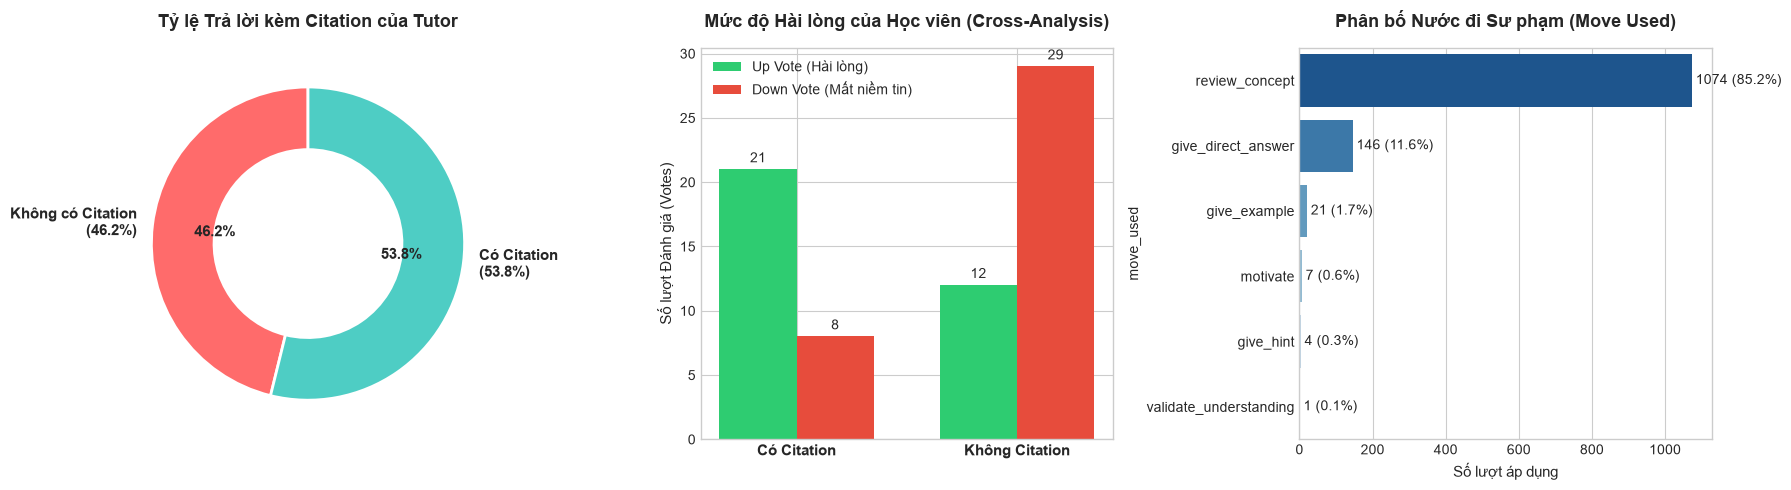

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình phong cách đồ họa hiện đại
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==========================================
# CHART 1: DONUT CHART - TỶ LỆ CITATION (Từ Block 2)
# ==========================================
has_cite_count = total_turns - no_cite_count
labels = [f'Không có Citation\n({no_cite_pct:.1f}%)', f'Có Citation\n({100-no_cite_pct:.1f}%)']
sizes = [no_cite_count, has_cite_count]
colors = ['#ff6b6b', '#4ecdc4']

axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, 
            wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2), textprops={'fontsize': 11, 'weight': 'bold'})
axes[0].set_title('Tỷ lệ Trả lời kèm Citation của Tutor', fontsize=13, fontweight='bold', pad=15)

# ==========================================
# CHART 2: GROUPED BAR CHART - RATING VS CITATION (Từ Block 4)
# ==========================================
categories = ['Có Citation', 'Không Citation']
up_votes = [up_with, up_no]
down_votes = [down_with, down_no]

x = np.arange(len(categories))
width = 0.35

rects1 = axes[1].bar(x - width/2, up_votes, width, label='Up Vote (Hài lòng)', color='#2ecc71')
rects2 = axes[1].bar(x + width/2, down_votes, width, label='Down Vote (Mất niềm tin)', color='#e74c3c')

axes[1].set_ylabel('Số lượt Đánh giá (Votes)', fontsize=11)
axes[1].set_title('Mức độ Hài lòng của Học viên (Cross-Analysis)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, fontsize=11, fontweight='bold')
axes[1].legend()

axes[1].bar_label(rects1, padding=3)
axes[1].bar_label(rects2, padding=3)

# ==========================================
# CHART 3: TOP PEDAGOGICAL MOVES (Từ DataFrame df ở Block 1)
# ==========================================
moves = tutors['move_used'].value_counts()
sns.barplot(x=moves.values, y=moves.index, ax=axes[2], palette='Blues_r')
axes[2].set_title('Phân bố Nước đi Sư phạm (Move Used)', fontsize=13, fontweight='bold', pad=15)
axes[2].set_xlabel('Số lượt áp dụng', fontsize=11)

for i, v in enumerate(moves.values):
    axes[2].text(v + 10, i, f"{v} ({v/total_turns*100:.1f}%)", va='center', fontsize=10)

plt.tight_layout()
plt.show()
